Imports the required libraries (NumPy, TensorFlow, Keras) and loads the 
preprocessed .npy files created in Week 1. This gives us the train, 
validation, and test sets ready for model building.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import (
EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)
X_tr = np.load("../data/X_train.npy")
X_val = np.load("../data/X_val.npy")
X_test = np.load("../data/X_test.npy")
y_tr = np.load("../data/y_train.npy")
y_val = np.load("../data/y_val.npy")
y_test = np.load("../data/y_test.npy")
NUM_CLASSES = y_tr.shape[1] # 383
SEQ_LEN = X_tr.shape[1] # 30
FEATURES = X_tr.shape[2] # 132
print(f"Classes: {NUM_CLASSES} | Frames: {SEQ_LEN} | Features: {FEATURES}")

Classes: 383 | Frames: 30 | Features: 132


Defines the LSTM neural network architecture. LSTM (Long Short-Term Memory) 
is used because sign language is a sequence — the model needs to remember 
what happened in earlier frames to understand the full gesture. Two LSTM 
layers extract temporal patterns, Dropout prevents overfitting, and the final 
Dense(383) layer outputs a probability score for each of the 383 signs.

In [2]:
model = Sequential([
LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, FEATURES)),
BatchNormalization(),
Dropout(0.3),
LSTM(64, return_sequences=False),
BatchNormalization(),
Dropout(0.3),
Dense(128, activation="relu"),
Dropout(0.2),
Dense(NUM_CLASSES, activation="softmax") # one output per sign
])
model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
loss="categorical_crossentropy",
metrics=["accuracy"]
)
model.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │       133,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 383)            │        49,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,535 (943.50 KB)

 Trainable params: 241,151 (942.00 KB)

 Non-trainable params: 384 (1.50 KB)

Trains the LSTM model for up to 100 epochs using three callbacks:
- EarlyStopping: stops training if the model stops improving, preventing wasted time
- ModelCheckpoint: automatically saves the best version of the model to lstm_best.keras
- ReduceLROnPlateau: halves the learning rate when progress stalls, helping the model fine-tune


In [3]:
callbacks = [
# Stop training if the model stops improving for 10 rounds
EarlyStopping(monitor="val_loss", patience=10,
restore_best_weights=True, verbose=1),
# Automatically save the best version of the model
ModelCheckpoint("ml/saved_models/lstm_best.keras",
monitor="val_accuracy", save_best_only=True, verbose=1),
# Halve the learning rate when progress stalls
ReduceLROnPlateau(monitor="val_loss", factor=0.5,
patience=5, min_lr=1e-6, verbose=1),
]
history = model.fit(
X_tr, y_tr,
epochs=100,
batch_size=32,
validation_data=(X_val, y_val),
callbacks=callbacks,
verbose=1
)

Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0122 - loss: 5.8144
Epoch 1: val_accuracy improved from None to 0.03150, saving model to ml/saved_models/lstm_best.keras

Epoch 1: finished saving model to ml/saved_models/lstm_best.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0202 - loss: 5.5659 - val_accuracy: 0.0315 - val_loss: 5.6851 - learning_rate: 0.0010
Epoch 2/100
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0419 - loss: 4.9991
Epoch 2: val_accuracy improved from 0.03150 to 0.04882, saving model to ml/saved_models/lstm_best.keras

Epoch 2: finished saving model to ml/saved_models/lstm_best.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0452 - loss: 4.9511 - val_accuracy: 0.0488 - val_loss: 5.3381 - learning_rate: 0.0010
Epoch 3/100
91/93 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0731 - loss: 4.6446
Epoch 3: val_accuracy did not improve from 0.04882
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0732 - loss: 4.6359 

Generates accuracy and loss curves to visually inspect how well the model 
trained. Plots are saved as lstm_curves.png. The final test accuracy is 
printed — this score is LSTM baseline that you will compare against 
GRU and CNN in Week 3.

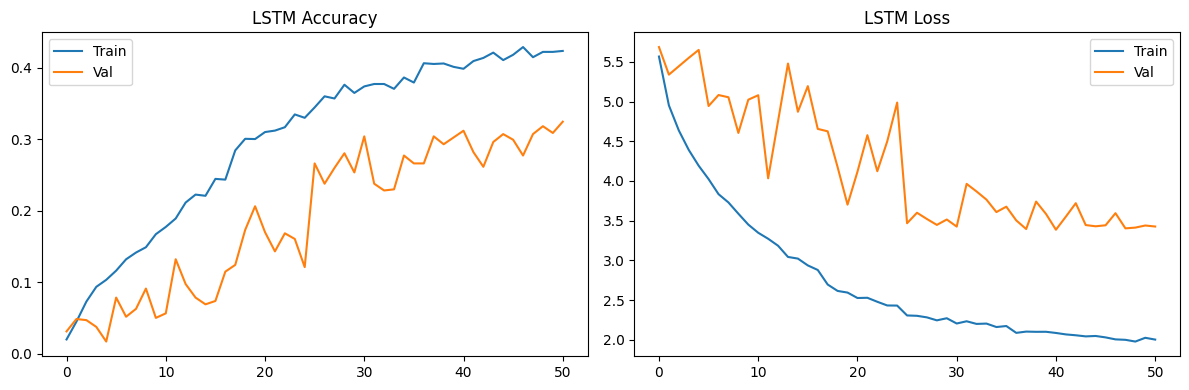

LSTM Test Accuracy: 31.13%


In [4]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Val")
ax1.set_title("LSTM Accuracy"); ax1.legend()
ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Val")
ax2.set_title("LSTM Loss"); ax2.legend()
plt.tight_layout()
plt.savefig("ml/saved_models/lstm_curves.png")
plt.show()
loss, lstm_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc*100:.2f}%")